X_train shape: (25, 5)
X_test shape: (7, 5)
y_train shape: (25,)
y_test shape: (7,)


C:\Users\student\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Test Accuracy: 0.000


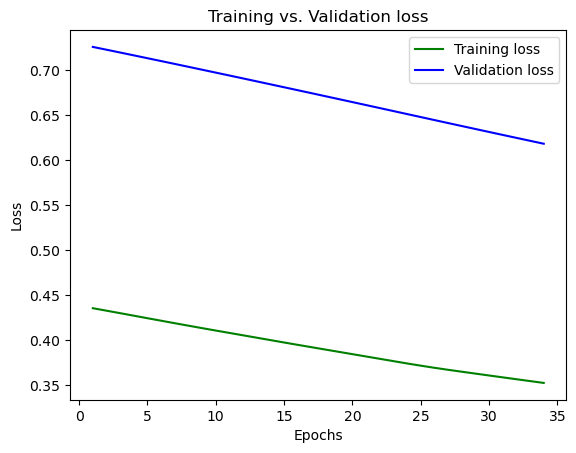

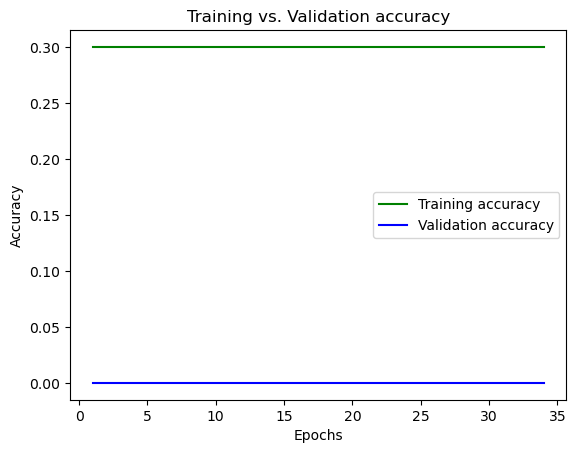

In [1]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from matplotlib import pyplot as plt
df = read_csv('Iris.csv')
X = df.values[:, :-1]
y = df.values[:, -1]
X = X.astype('float32')
y = LabelEncoder().fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=123
)
print("X_train shape: {}".format(X_train.shape))
print("X_test shape: {}".format(X_test.shape))
print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=1
)
n_features = X_train.shape[1]
model = keras.Sequential([
    keras.layers.Flatten(
        input_shape=(n_features,)
    ),
    keras.layers.Dense(
        4,
        activation=tf.nn.relu
    ),
    keras.layers.Dense(
        4,
        activation=tf.nn.relu
    ),

    keras.layers.Dense(
        1,
        activation=tf.nn.sigmoid
    )

])
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['accuracy']
)
history = model.fit(
    X_train,
    y_train,
    epochs=34,
    batch_size=32,
    verbose=0,
    validation_data=(X_val, y_val)
)
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print('Test Accuracy: %.3f' % acc)

loss_train = history.history['loss']
loss_val = history.history['val_loss']

epochs = range(1, 35)

plt.plot(
    epochs,
    loss_train,
    'g',
    label='Training loss'
)

plt.plot(
    epochs,
    loss_val,
    'b',
    label='Validation loss'
)

plt.title('Training vs. Validation loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()
accuracy_train = history.history['accuracy']
accuracy_val = history.history['val_accuracy']

epochs = range(1, 35)

plt.plot(
    epochs,
    accuracy_train,
    'g',
    label='Training accuracy'
)
plt.plot(
    epochs,
    accuracy_val,
    'b',
    label='Validation accuracy'
)

plt.title('Training vs. Validation accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()